## Boston House Price Prediction

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv('data/boston.csv')

### Boston House Prices Dataset

#### Dataset Overview
The Boston House Prices dataset is a widely used dataset for regression problems in machine learning. It contains information collected by the U.S. Census Service concerning housing in the Boston area.

---

#### Dataset Characteristics

- **Number of Instances:** 506  
- **Number of Attributes:** 13 predictive attributes  
- **Target Variable:** `MEDV` (Median value of owner-occupied homes in \$1000s)

---

#### Attribute Information

| Attribute | Description |
|---|---|
| **CRIM** | Per capita crime rate by town |
| **ZN** | Proportion of residential land zoned for lots over 25,000 sq.ft. |
| **INDUS** | Proportion of non-retail business acres per town |
| **CHAS** | Charles River dummy variable (1 if tract bounds river, 0 otherwise) |
| **NOX** | Nitric oxides concentration (parts per 10 million) |
| **RM** | Average number of rooms per dwelling |
| **AGE** | Proportion of owner-occupied units built prior to 1940 |
| **DIS** | Weighted distances to five Boston employment centers |
| **RAD** | Index of accessibility to radial highways |
| **TAX** | Full-value property-tax rate per \$10,000 |
| **PTRATIO** | Pupil-teacher ratio by town |
| **B** | `1000(Bk - 0.63)^2` where `Bk` is the proportion of Black residents by town |
| **LSTAT** | Percentage of lower status population |
| **MEDV** | Median value of owner-occupied homes (in \$1000s) |

---

#### Missing Values

- **Missing Attribute Values:** None

---

#### Dataset Source

This dataset is a copy of the UCI Machine Learning Housing Dataset:

https://archive.ics.uci.edu/ml/machine-learning-databases/housing/

The dataset was originally taken from the StatLib library maintained at Carnegie Mellon University.

---

#### Original Research Source

The dataset was introduced in:

- Harrison, D. and Rubinfeld, D.L.  
  *"Hedonic Prices and the Demand for Clean Air"*  
  Journal of Environmental Economics & Management, Vol. 5, pp. 81–102, 1978.

The data was later used in:

- Belsley, Kuh & Welsch  
  *"Regression Diagnostics: Identifying Influential Data and Sources of Collinearity"*  
  Wiley, 1980.

---

#### Usage in Machine Learning

The Boston Housing dataset has been extensively used in machine learning research for regression tasks and predictive modeling.

---

#### References

1. Belsley, Kuh & Welsch (1980)  
   *Regression Diagnostics: Identifying Influential Data and Sources of Collinearity*  
   Wiley, pp. 244–261.

2. Quinlan, R. (1993)  
   *Combining Instance-Based and Model-Based Learning*  
   Proceedings of the Tenth International Conference on Machine Learning, pp. 236–243.

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [5]:
df.rename(columns={'MEDV':'Price'}, inplace=True)
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [7]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [8]:
# Check the missing values
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
Price       0
dtype: int64

In [9]:
df[df.isnull().any(axis=1)]

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
6,0.08829,12.5,7.87,NaN,0.524,6.012,66.6,5.5605,5,311,15.2,395.60,12.43,22.9
9,0.17004,12.5,7.87,NaN,0.524,6.004,85.9,6.5921,5,311,15.2,386.71,17.10,18.9
14,0.63796,0.0,8.14,NaN,0.538,6.096,84.5,4.4619,4,307,21.0,380.02,10.26,18.2
35,0.06417,0.0,5.96,0.0,0.499,5.933,68.2,3.3603,5,279,19.2,396.90,NaN,18.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,4.64689,0.0,18.10,0.0,0.614,6.980,67.6,2.5329,24,666,20.2,374.68,NaN,29.8
479,14.33370,0.0,18.10,NaN,0.614,6.229,88.0,1.9512,24,666,20.2,383.32,13.11,21.4
482,5.73116,0.0,18.10,NaN,0.532,7.061,77.0,3.4106,24,666,20.2,395.28,7.01,25.0
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4


In [10]:
# Fill the missing values with median values of respective columns
df.fillna(df.median(numeric_only=True), inplace=True)

In [11]:
df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
Price      0
dtype: int64

### Analyzing The Correlated Features

In [12]:
# EDA
df.corr()   # Correlation

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
CRIM,1.000000,-0.185359,0.392632,-0.055585,0.410971,-0.220045,0.343427,-0.366025,0.601224,0.560469,0.277964,-0.365336,0.437417,-0.383895
ZN,-0.185359,1.000000,-0.507304,-0.032992,-0.498619,0.312295,-0.535341,0.632428,-0.300061,-0.304385,-0.394622,0.170125,-0.398838,0.362292
INDUS,0.392632,-0.507304,1.000000,0.054693,0.738387,-0.377978,0.614248,-0.698621,0.592735,0.716267,0.385366,-0.354840,0.564508,-0.476394
CHAS,-0.055585,-0.032992,0.054693,1.000000,0.070867,0.106797,0.074984,-0.092318,-0.003339,-0.035822,-0.109451,0.050608,-0.047279,0.183844
NOX,0.410971,-0.498619,0.738387,0.070867,1.000000,-0.302188,0.711864,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.573040,-0.427321
RM,-0.220045,0.312295,-0.377978,0.106797,-0.302188,1.000000,-0.239518,0.205246,-0.209847,-0.292048,-0.355501,0.128069,-0.604323,0.695360
AGE,0.343427,-0.535341,0.614248,0.074984,0.711864,-0.239518,1.000000,-0.724354,0.447088,0.498408,0.261826,-0.268029,0.575022,-0.377572
DIS,-0.366025,0.632428,-0.698621,-0.092318,-0.769230,0.205246,-0.724354,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.483244,0.249929
RAD,0.601224,-0.300061,0.592735,-0.003339,0.611441,-0.209847,0.447088,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.467765,-0.381626
TAX,0.560469,-0.304385,0.716267,-0.035822,0.668023,-0.292048,0.498408,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.524156,-0.468536


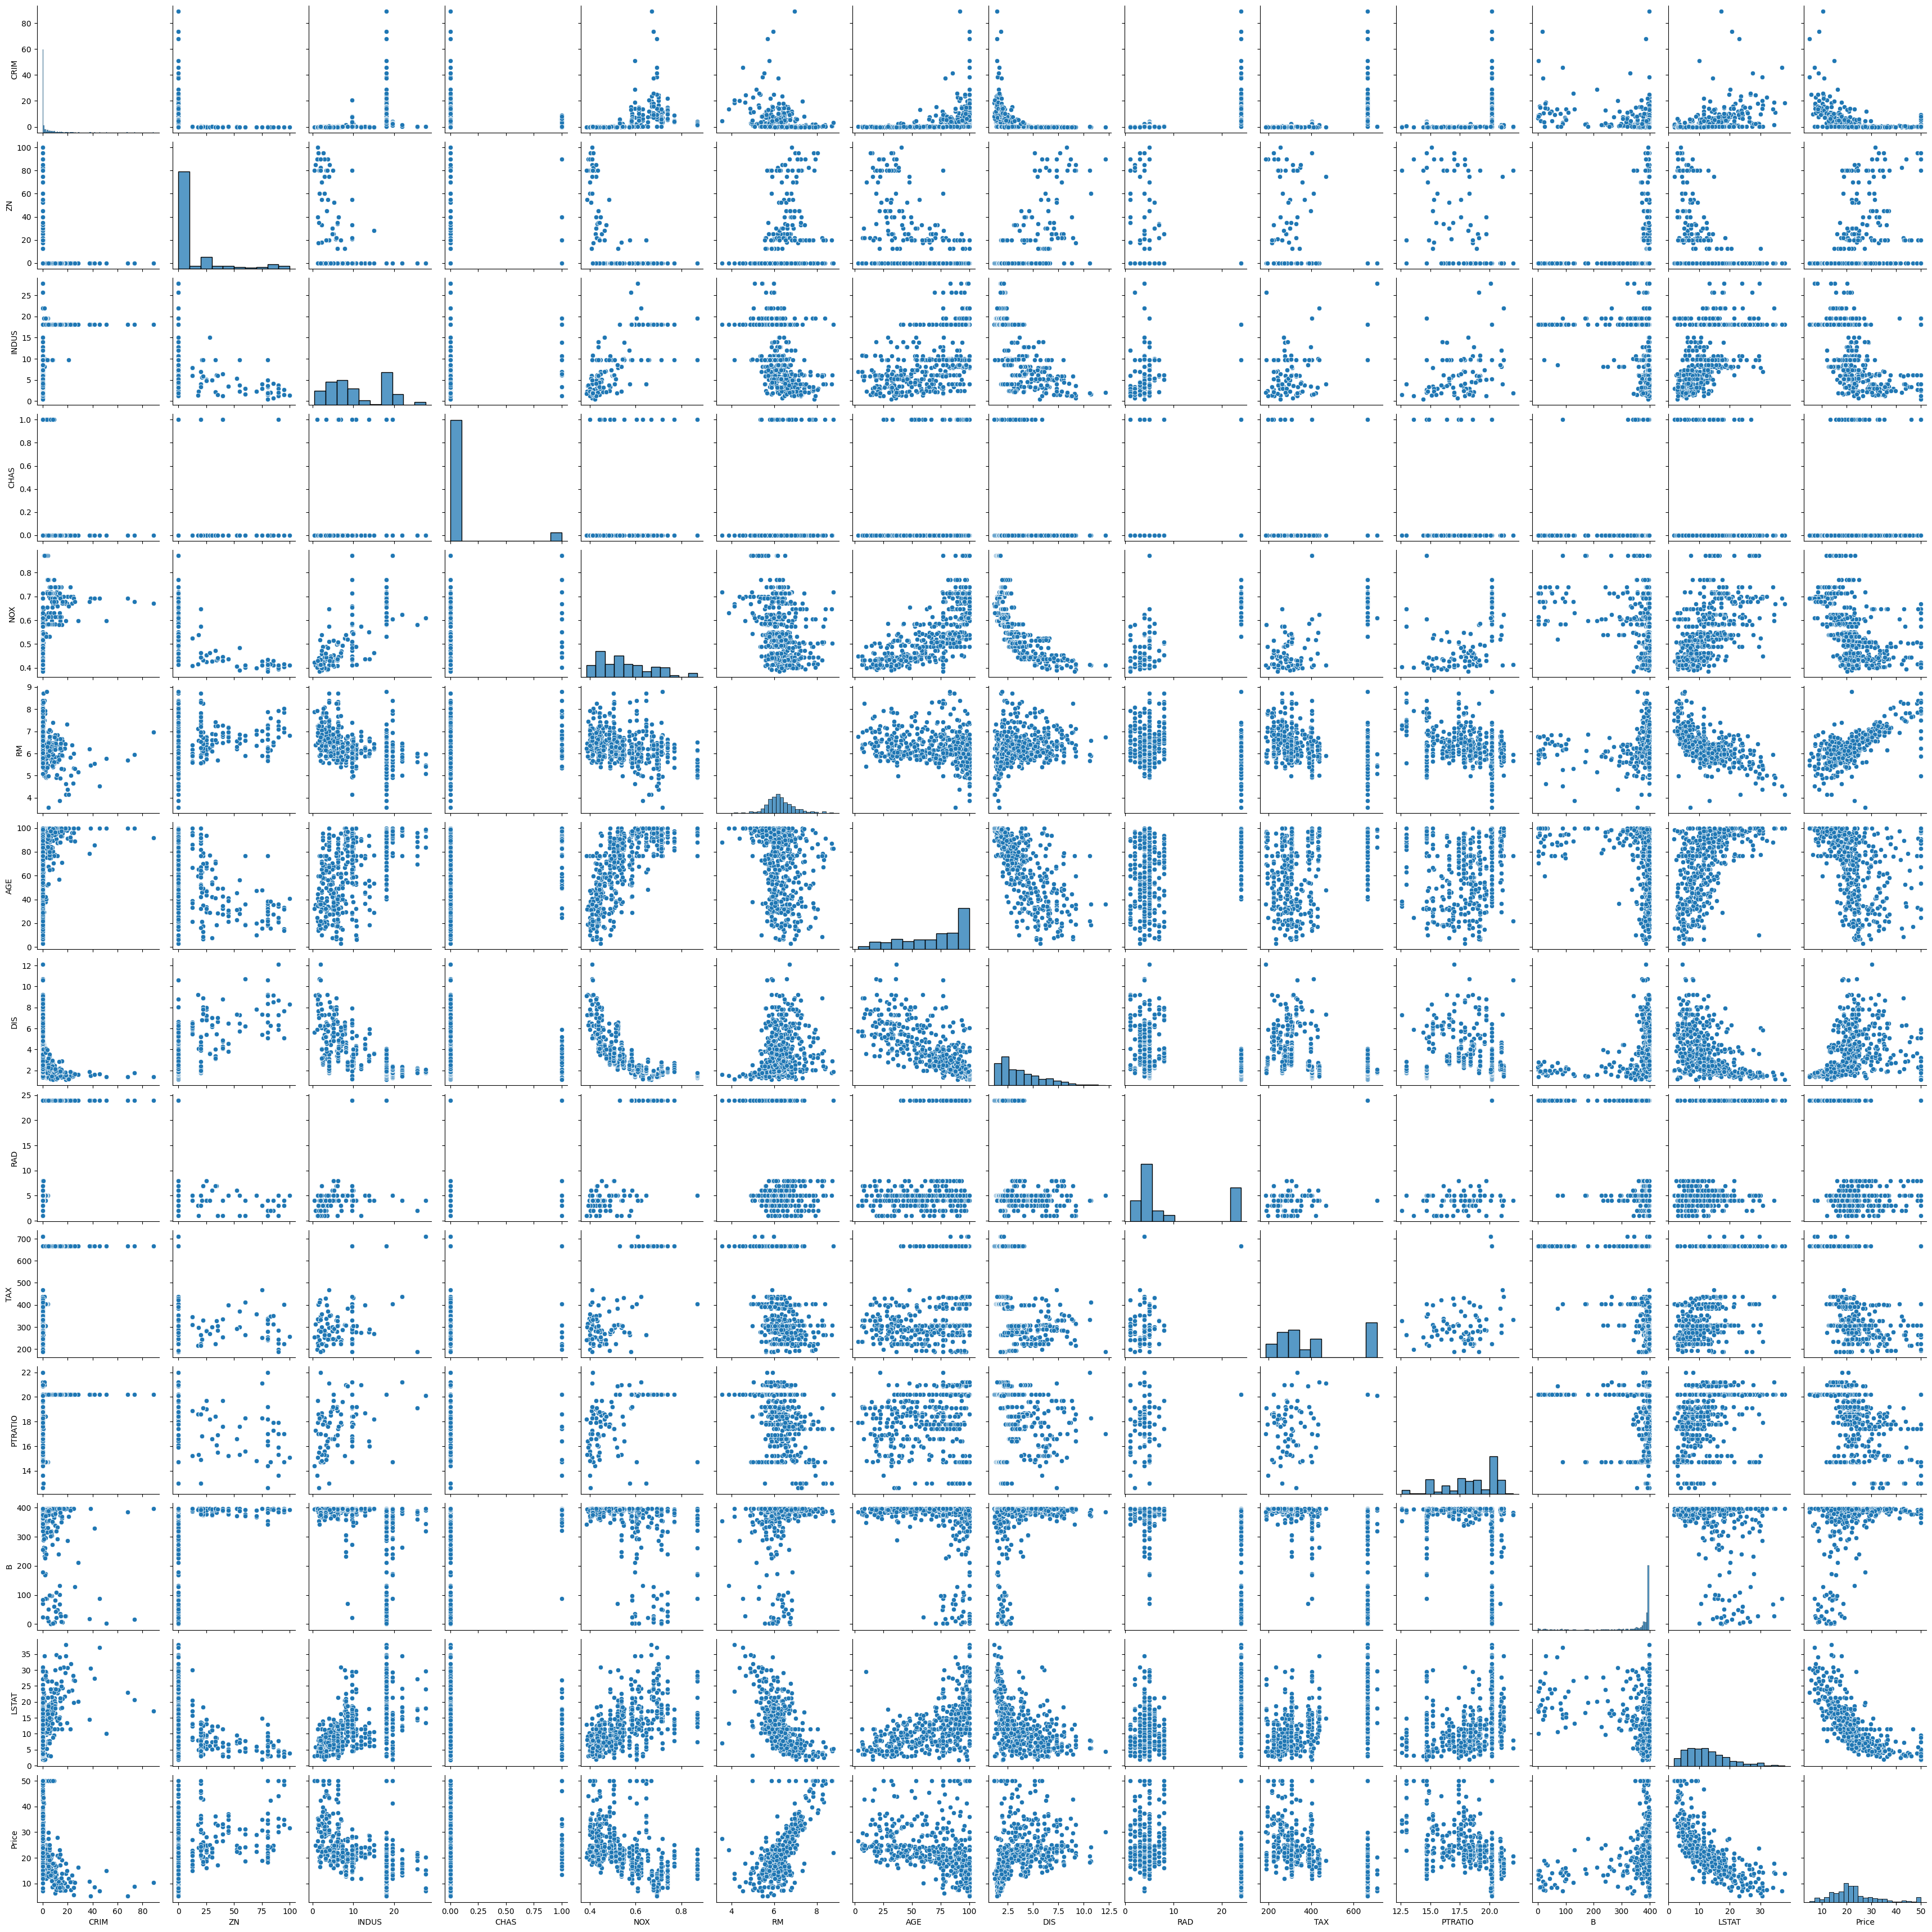

In [13]:
import seaborn as sns
sns.pairplot(df)

<Axes: >

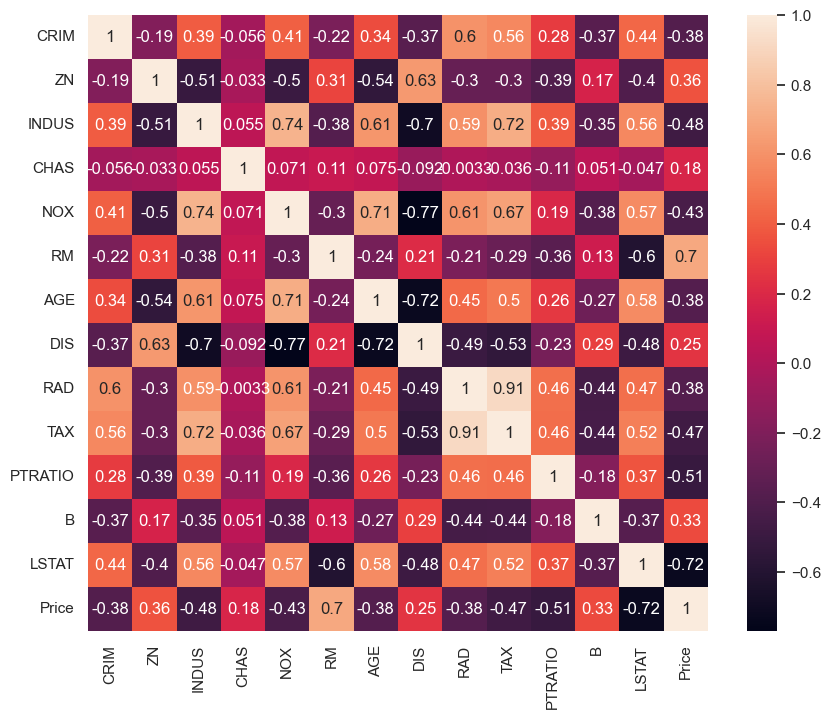

In [14]:
sns.set(rc={'figure.figsize':(10,8)})
sns.heatmap(df.corr(),annot=True)

Text(0, 0.5, 'Price')

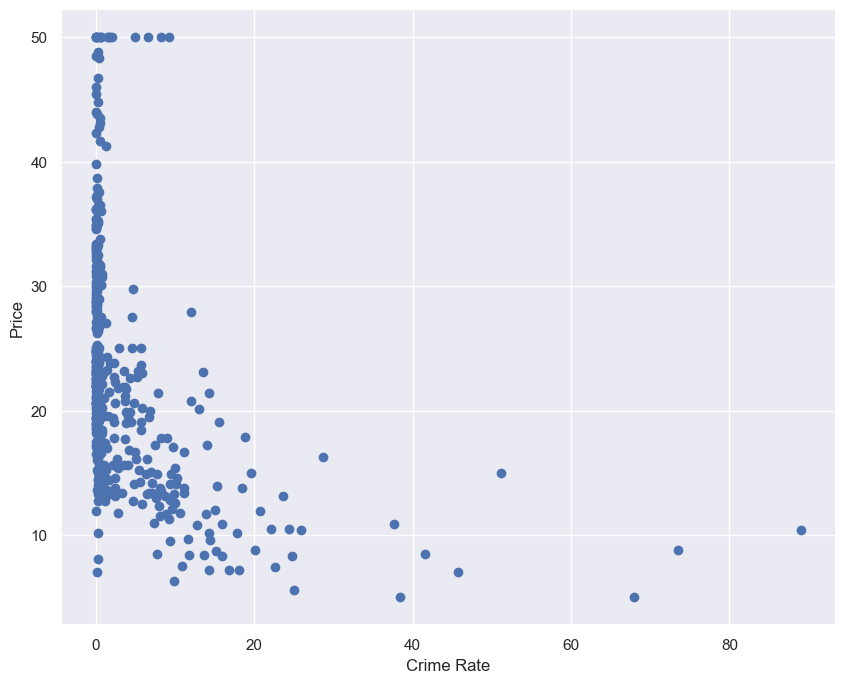

In [15]:
plt.scatter(df['CRIM'],df['Price'])
plt.xlabel("Crime Rate")
plt.ylabel("Price")

Text(0, 0.5, 'Price')

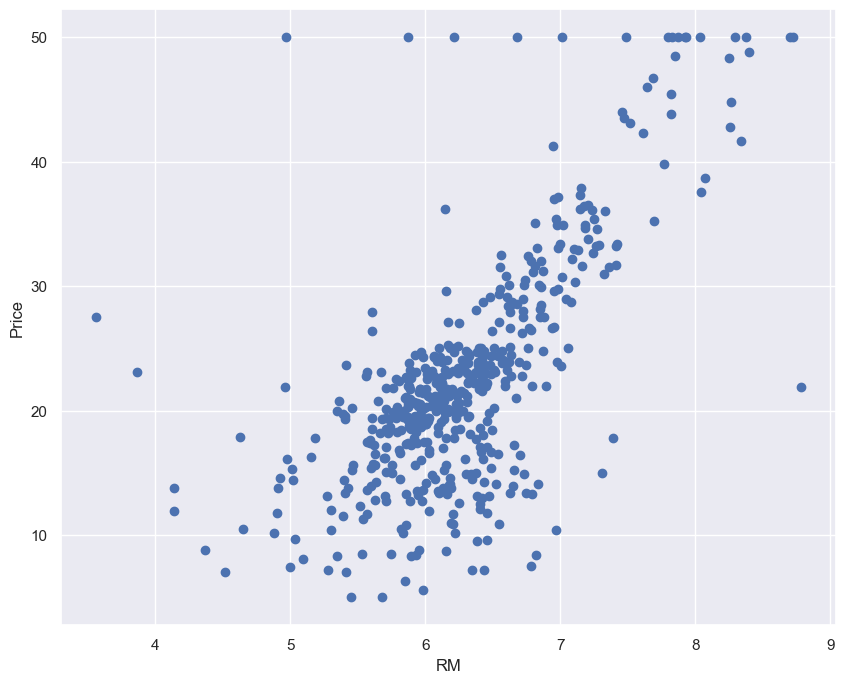

In [16]:
plt.scatter(df['RM'],df['Price'])
plt.xlabel("RM")
plt.ylabel("Price")

<Axes: xlabel='RM', ylabel='Price'>

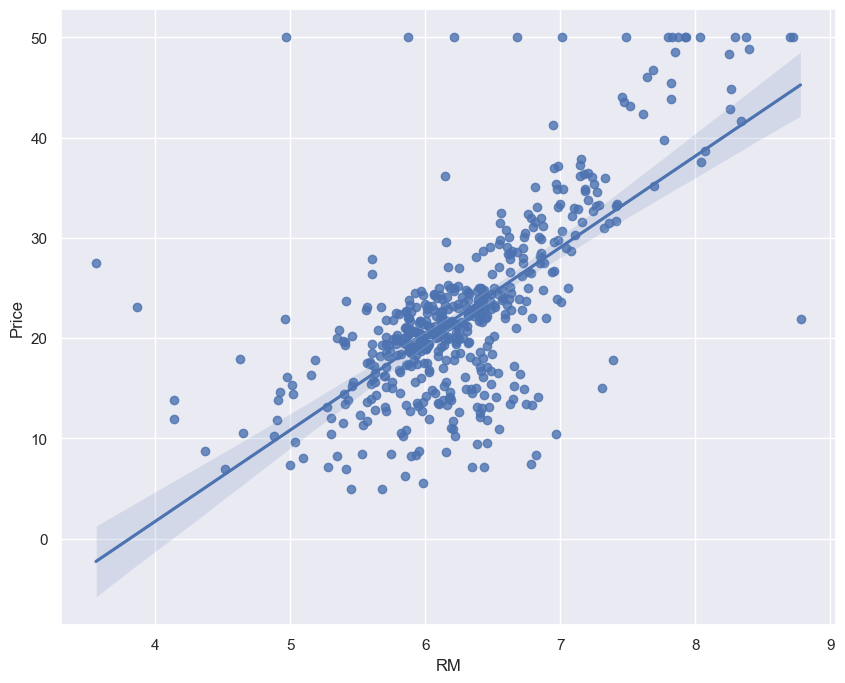

In [17]:
sns.regplot(x="RM",y="Price",data=df)

<Axes: xlabel='LSTAT', ylabel='Price'>

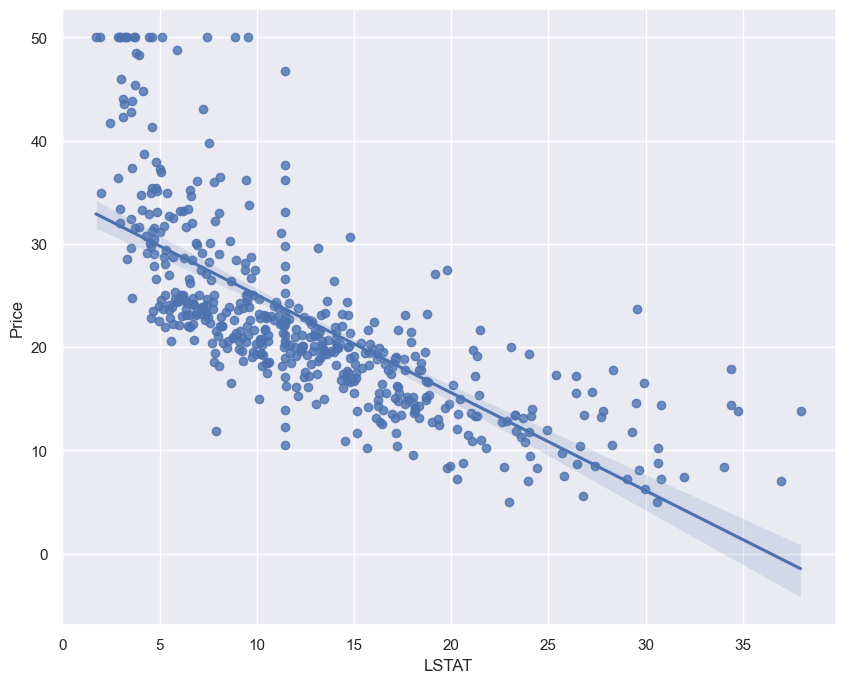

In [18]:
sns.regplot(x="LSTAT",y="Price",data=df)

<Axes: xlabel='CHAS', ylabel='Price'>

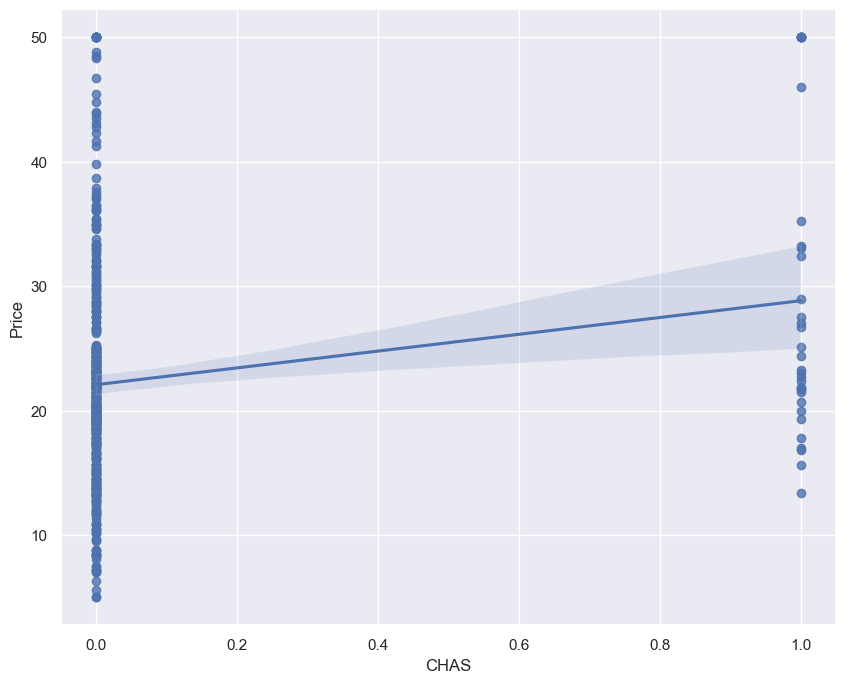

In [19]:
sns.regplot(x="CHAS",y="Price",data=df)

<Axes: xlabel='CRIM', ylabel='Price'>

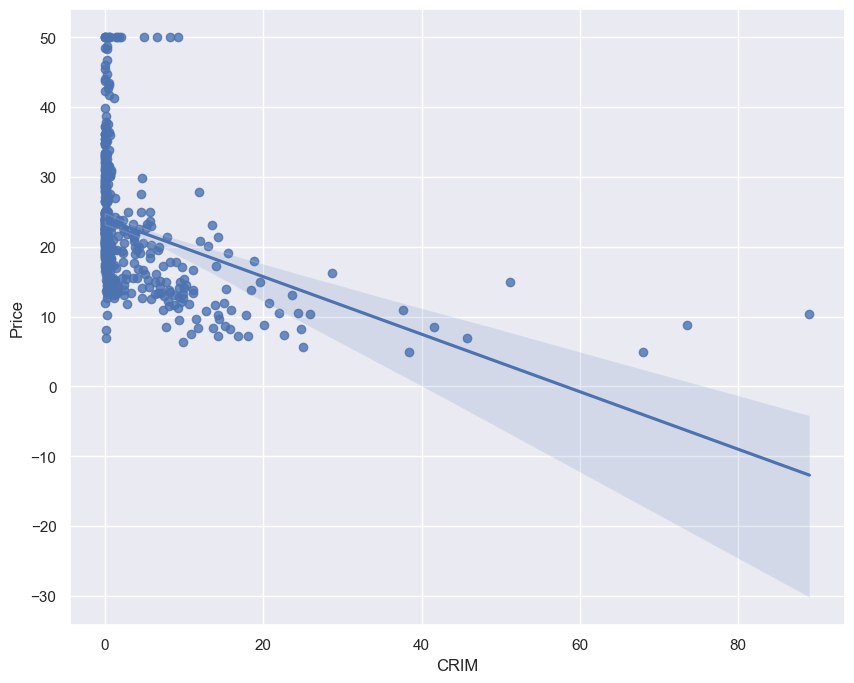

In [20]:
sns.regplot(x="CRIM",y="Price",data=df)

<Axes: xlabel='PTRATIO', ylabel='Price'>

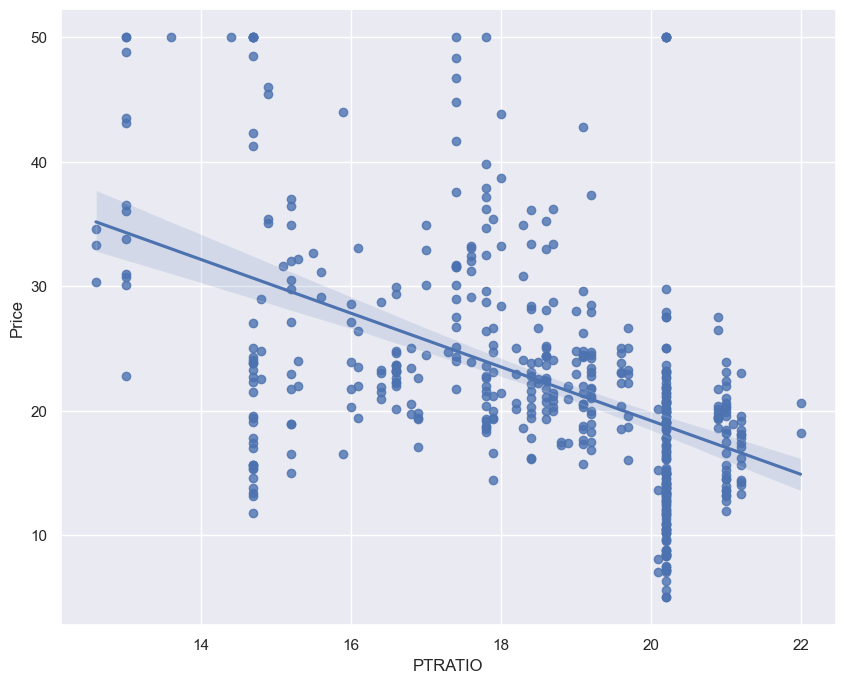

In [21]:
sns.regplot(x="PTRATIO",y="Price",data=df)

<Axes: ylabel='CRIM'>

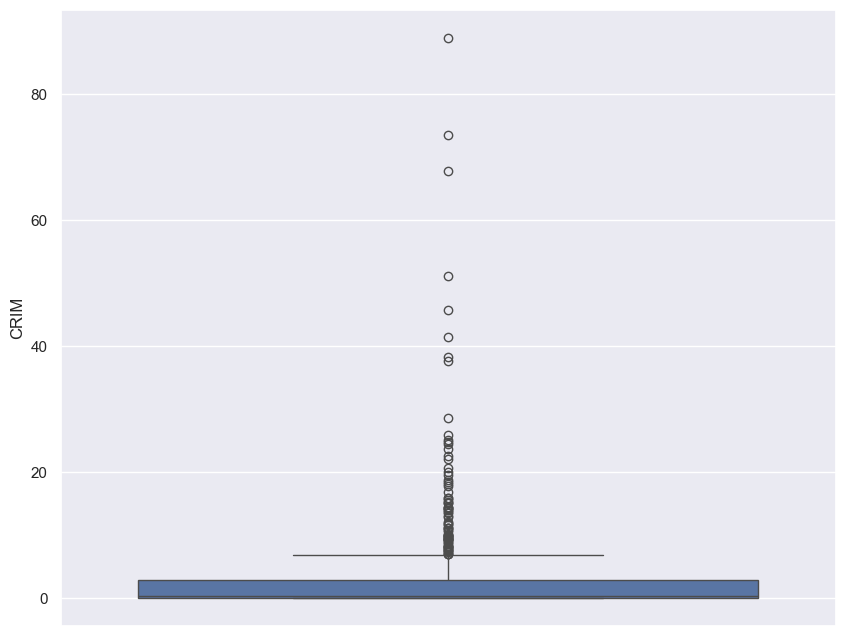

In [22]:
sns.boxplot(df['CRIM'])

In [23]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2


In [24]:
# Independent And Dependent Features
X=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [25]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43


In [26]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

In [27]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [28]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3,222,18.7,394.12,5.21
116,0.13158,0.0,10.01,0.0,0.547,6.176,72.5,2.7301,6,432,17.8,393.30,11.43
45,0.17142,0.0,6.91,0.0,0.448,5.682,33.8,5.1004,3,233,17.9,396.90,10.21
16,1.05393,0.0,8.14,0.0,0.538,5.935,29.3,4.4986,4,307,21.0,386.85,6.58
468,15.57570,0.0,18.10,0.0,0.580,5.926,71.0,2.9084,24,666,20.2,368.74,18.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0.0,0.520,5.836,91.9,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.0,6.96,0.0,0.464,5.856,42.1,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.0,2.01,0.0,0.435,6.635,29.7,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.0,18.10,0.0,0.740,6.629,94.6,2.1247,24,666,20.2,109.85,23.27


In [29]:
X_train.shape

(354, 13)

In [30]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,9.69,0.0,0.510,6.416,76.8,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.41,1.0,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.74,0.0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.81,0.0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.10,0.0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
441,9.72418,0.0,18.10,0.0,0.740,6.406,97.2,2.0651,24,666,20.2,385.96,11.43
23,0.98843,0.0,8.14,0.0,0.538,5.813,100.0,4.0952,4,307,21.0,394.54,19.88
225,0.52693,0.0,6.20,0.0,0.504,8.725,83.0,2.8944,8,307,17.4,382.00,4.63
433,5.58107,0.0,18.10,0.0,0.713,6.436,87.9,2.3158,24,666,20.2,100.19,16.22


In [31]:
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: Price, Length: 506, dtype: float64

In [32]:
y_train.shape

(354,)

In [33]:
X_test.shape

(152, 13)

In [34]:
y_test.shape

(152,)

In [35]:
# Standardize or feature scaling the datasets
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [36]:
scaler

StandardScaler()

In [37]:
X_train=scaler.fit_transform(X_train)

In [38]:
X_test=scaler.transform(X_test)

In [39]:
X_train

array([[-0.39906845, -0.48778231, -1.30614484, ...,  0.18727079,
         0.39651419, -1.03822208],
       [-0.38677159, -0.48778231, -0.14397651, ..., -0.21208981,
         0.3870674 , -0.14317123],
       [-0.38195583, -0.48778231, -0.60409424, ..., -0.16771641,
         0.42854113, -0.31872783],
       ...,
       [-0.40086227,  3.07160832, -1.3313771 , ..., -0.56707702,
         0.35987906, -0.92598098],
       [ 0.94636406, -0.48778231,  1.05678233, ...,  0.8528718 ,
        -2.87841346,  1.56059117],
       [-0.37502472, -0.48778231, -0.35919287, ...,  1.16348561,
        -3.32828832, -0.25829031]], shape=(354, 13))

In [40]:
X_test

array([[-0.39158251, -0.48778231, -0.19147254, ..., -0.74457062,
         0.41241246, -0.48708948],
       [-0.39585432,  1.291913  , -0.67830678, ..., -0.30083661,
         0.42854113, -1.27997215],
       [-0.38989506, -0.48778231,  2.48760003, ...,  0.8084984 ,
         0.35031705,  0.81231715],
       ...,
       [-0.33898269, -0.48778231, -0.70947604, ..., -0.38958342,
         0.25688594, -1.12168342],
       [ 0.27194887, -0.48778231,  1.05678233, ...,  0.8528718 ,
        -2.98970133,  0.54610427],
       [ 0.79701392, -0.48778231,  1.05678233, ...,  0.8528718 ,
         0.33199949,  0.57776202]], shape=(152, 13))

### Model Training

In [41]:
from sklearn.linear_model import LinearRegression

In [42]:
regression=LinearRegression()

In [43]:
regression

LinearRegression()

In [44]:
regression.fit(X_train,y_train)

LinearRegression()

In [45]:
# print the coefficients and the intercept
print(regression.coef_)

[-1.03139352  0.68235072 -0.05344167  0.95797829 -1.61846531  3.14830411
 -0.65443065 -2.98754714  1.64431524 -1.17863385 -2.00667634  1.00071526
 -3.34283682]


In [46]:
print(regression.intercept_)

23.01581920903955


In [47]:
# on which parameters the model has been trained
regression.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [48]:
# Prediction for the test data
reg_pred=regression.predict(X_test)

In [49]:
reg_pred

array([28.74796697, 37.04276981, 15.23648947, 25.57965227, 18.4598692 ,
       22.95780707, 17.76850542, 14.38571217, 22.03723629, 20.796854  ,
       25.16699768, 18.51966638, -6.22880411, 21.87874844, 19.05911392,
       25.92922218, 19.3934137 ,  5.61048116, 40.70614094, 17.14502899,
       25.42004954, 30.2613306 , 11.39021059, 23.35145746, 17.4879536 ,
       15.09897977, 21.9909183 , 14.50652624, 22.83647869, 19.54687218,
       22.17131402, 25.26099979, 24.99671977, 17.36761266, 16.16822936,
       17.36263859, 30.95455472, 20.38362751, 24.70846444, 23.39340539,
       14.4632438 , 31.68885585, 42.62429658, 17.98408565, 27.34827935,
       16.52654044, 13.96867708, 26.49229684, 19.68936425, 30.28704199,
       21.09514632, 33.2905181 , 15.96674251, 26.26129713, 39.53495509,
       22.45120293, 18.43260546, 32.87791268, 25.23294135, 12.9442509 ,
       22.82835929, 30.8937041 , 31.9036883 , 16.74514578, 21.27346987,
       17.15682196, 19.93344794, 26.3380121 , 31.15946499, 11.74

### Assumptions Of Linear Regression

Text(0, 0.5, 'Test Predicted Data')

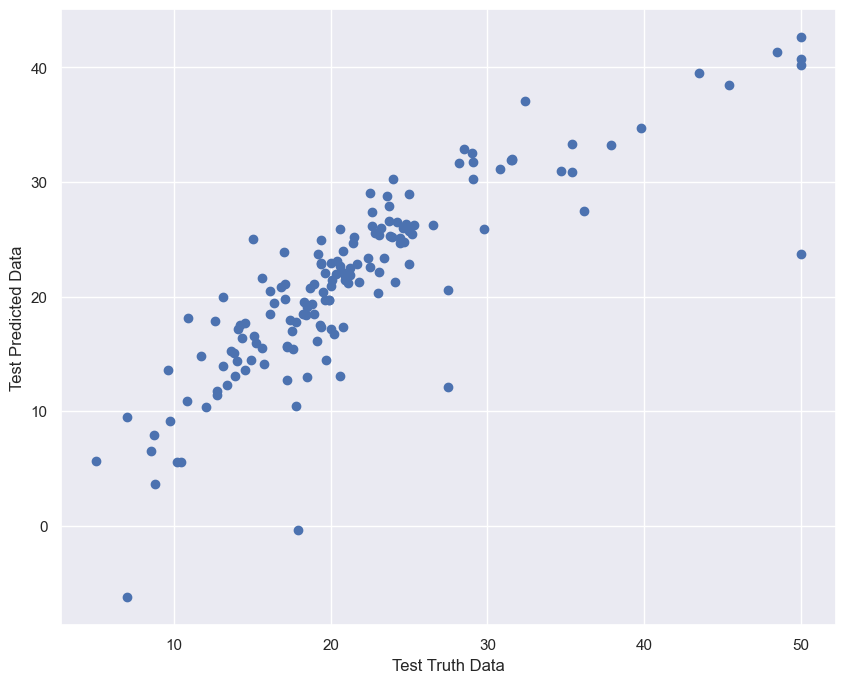

In [50]:
# plot a scatter plot for the prediction
plt.scatter(y_test,reg_pred)
plt.xlabel("Test Truth Data")
plt.ylabel("Test Predicted Data")

In [51]:
# residuals
residuals=y_test-reg_pred

In [52]:
residuals

173   -5.147967
274   -4.642770
491   -1.636489
72    -2.779652
452   -2.359869
         ...   
441   -3.999660
23     0.898661
225    9.826344
433   -2.097165
447   -5.242309
Name: Price, Length: 152, dtype: float64

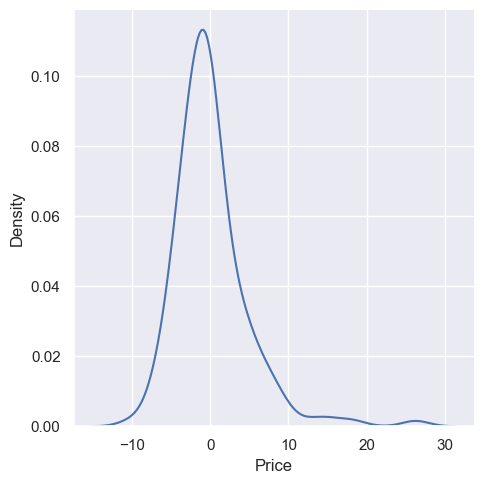

In [53]:
# Plot this residuals 
sns.displot(residuals,kind="kde")

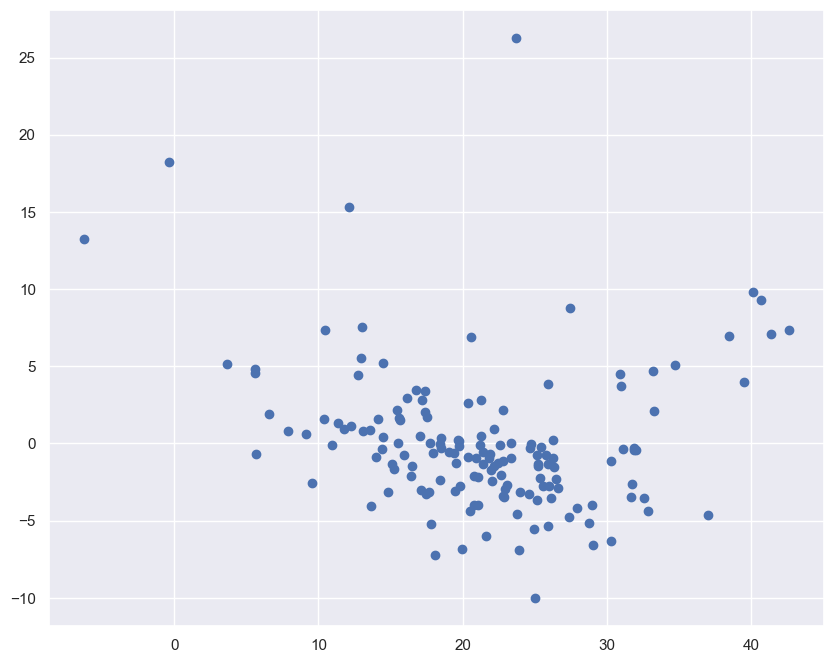

In [54]:
# Scatter plot with predictions and residual
# uniform distribution
plt.scatter(reg_pred,residuals)

In [55]:
# Performance Metrics
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

print(mean_squared_error(y_test,reg_pred))
print(mean_absolute_error(y_test,reg_pred))
print(np.sqrt(mean_squared_error(y_test,reg_pred)))

21.784360758791156
3.140754511984167
4.667371932768071


### R square and adjusted R square


Formula

**R^2 = 1 - SSR/SST**


R^2	=	coefficient of determination
SSR	=	sum of squares of residuals
SST	=	total sum of squares


In [56]:
from sklearn.metrics import r2_score
score=r2_score(y_test,reg_pred)
print(score)

0.7076438632327413


In [57]:
# Adjusted R square
# display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.6801030677401735

**Adjusted R2 = 1 – [(1-R2)*(n-1)/(n-k-1)]**

where:

R2: The R2 of the model
n: The number of observations
k: The number of predictor variables

In [58]:
# Ridge
from sklearn.linear_model import Ridge
ridge=Ridge()

In [59]:
ridge.fit(X_train,y_train)

Ridge()

In [60]:
ridge.predict(X_test)

array([28.70689548, 36.99780736, 15.3227475 , 25.5691794 , 18.45577115,
       22.95988373, 17.78672614, 14.41133694, 21.99392822, 20.81028295,
       25.14925993, 18.55991914, -6.17545114, 21.89612978, 19.06996046,
       25.89484923, 19.32940088,  5.61095899, 40.64397859, 17.14510801,
       25.38857843, 30.20458783, 11.4353729 , 23.35983957, 17.47911426,
       15.06718123, 21.99478969, 14.52600248, 22.84560966, 19.56612509,
       22.14821267, 25.26216897, 24.97760203, 17.36468885, 16.13846192,
       17.41247145, 30.95742242, 20.39278469, 24.71840001, 23.38893139,
       14.48682169, 31.61330791, 42.52736407, 18.01922416, 27.34211312,
       16.51231714, 14.00173834, 26.48349976, 19.65978723, 30.30406552,
       21.12421801, 33.24821601, 16.00264935, 26.27332445, 39.484227  ,
       22.43097693, 18.42931045, 32.80776397, 25.23277301, 12.98224198,
       22.85270515, 30.8742348 , 31.85779295, 16.76664465, 21.38078105,
       17.17149782, 19.91710349, 26.32681172, 31.11240598, 11.75